In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, average_precision_score, PrecisionRecallDisplay, precision_recall_curve, recall_score
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.naive_bayes import GaussianNB,  CategoricalNB, MultinomialNB
from sklearn.preprocessing import KBinsDiscretizer, LabelEncoder

## Load data

In [6]:
df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_1.0,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,-1.085628,0,0,0,1,5,0,1,1,1,0,0,0,0,0,0
1,3,0.420314,0,1,0,1,5,0,1,1,1,0,0,0,0,0,0


In [7]:
df.shape

(6430, 17)

In [8]:
# Define columns
continuous_features = ['child_weight']
categorical_features = [
    'child_age', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area',
    'child_sex', 'mother_education', 'health_insurance', 'wealth_index'
]
one_hot_provinces = [
    'province_1.0', 'province_2.0', 'province_3.0', 'province_4.0',
    'province_5.0', 'province_6.0', 'province_7.0'
]
target = 'malnurished'

# Separate datasets
X_cont = df[continuous_features]
X_cat = df[categorical_features + one_hot_provinces]
y = df[target]

In [9]:
# Train/test split
X_cont_train, X_cont_test, X_cat_train, X_cat_test, y_train, y_test = train_test_split(
    X_cont, X_cat, y, test_size=0.2, random_state=42
)

X_train_combined = pd.concat([X_cont_train.reset_index(drop=True), X_cat_train.reset_index(drop=True)], axis=1)

In [10]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_combined, y_train)

X_cont_train_sm = X_train_sm[continuous_features]
X_cat_train_sm = X_train_sm.drop(columns=continuous_features)

In [11]:
print('Before SMOTE: ', Counter(y_train))
print('After SMOTE: ', Counter(y_train_sm))

Before SMOTE:  Counter({0: 2828, 1: 2316})
After SMOTE:  Counter({1: 2828, 0: 2828})


In [12]:
# Train models
gnb = GaussianNB()
cnb = CategoricalNB()

gnb.fit(X_cont_train_sm, y_train_sm)
cnb.fit(X_cat_train_sm, y_train_sm)

CategoricalNB()

In [13]:
# Predict
log_prob_cont = gnb.predict_log_proba(X_cont_test)
log_prob_cat = cnb.predict_log_proba(X_cat_test)

log_prob_combined = log_prob_cont + log_prob_cat

In [14]:
y_pred = np.argmax(log_prob_combined, axis=1)
print("Classification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.61      0.65       707
           1       0.58      0.67      0.62       579

    accuracy                           0.64      1286
   macro avg       0.64      0.64      0.64      1286
weighted avg       0.64      0.64      0.64      1286



In [15]:
# Define parameter grid
params = { 
    'alpha': [0.001, 0.01, 0.1, 0.5, 1.0],       # Laplace smoothing
    'fit_prior': [True, False]                  # Use prior or uniform class priors
}

# Use recall for positive class (malnurished = 1)
recall_scorer = make_scorer(recall_score, pos_label=1)

# Initialize model
cnb_params = CategoricalNB()

# Grid Search with 10-fold CV
grid_search = GridSearchCV(
    estimator= cnb_params,
    param_grid=params,
    scoring=recall_scorer,   # Explicit custom scorer for positive class
    cv=10,
    n_jobs=-1,
    verbose=1
)

# Fit the model to your categorical training data
grid_search.fit(X_cat_train_sm, y_train_sm)

Fitting 10 folds for each of 10 candidates, totalling 100 fits


GridSearchCV(cv=10, estimator=CategoricalNB(), n_jobs=-1,
             param_grid={'alpha': [0.001, 0.01, 0.1, 0.5, 1.0],
                         'fit_prior': [True, False]},
             scoring=make_scorer(recall_score, pos_label=1), verbose=1)

In [16]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'alpha': 0.001, 'fit_prior': True}
Best Cross-Validation Accuracy: 0.6223517028794827


In [17]:
# Fit GaussianNB on sm continuous data
gnb = GaussianNB()
gnb.fit(X_cont_train_sm, y_train_sm)

# Fit tuned CategoricalNB on sm categorical data
cnb_tune = grid_search.best_estimator_
cnb_tune.fit(X_cat_train_sm, y_train_sm)

# Predict on original test set (unchanged!)
log_prob_cont = gnb.predict_log_proba(X_cont_test)
log_prob_cat = cnb_tune.predict_log_proba(X_cat_test)
log_prob_combined = log_prob_cont + log_prob_cat
y_pred_combined = np.argmax(log_prob_combined, axis=1)

print("Classification Report:\n", classification_report(y_test, y_pred_combined))

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.61      0.65       707
           1       0.58      0.67      0.62       579

    accuracy                           0.64      1286
   macro avg       0.64      0.64      0.64      1286
weighted avg       0.64      0.64      0.64      1286



### Average Precision Score

In [18]:
prob_combined = np.exp(log_prob_combined) # convert log probs to probabilities
y_probas = prob_combined[:, 1] 

# Compute Average Precision Score
average_precision_score(y_test, y_probas)

0.6163511441558642

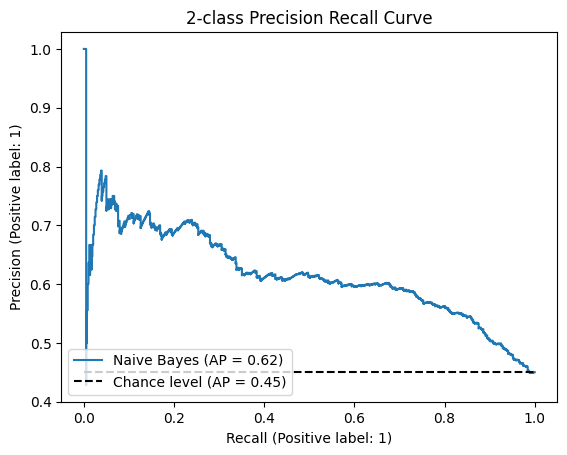

In [19]:
display = PrecisionRecallDisplay.from_predictions(
    y_test,
    prob_combined[:, 1],        # Probability for class 1 (malnourished)
    name="Naive Bayes",
    plot_chance_level=True
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()


### Confusion matrix

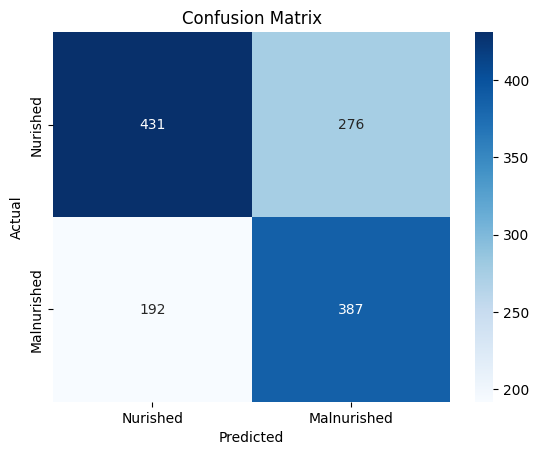

In [20]:
cm = confusion_matrix(y_test, y_pred_combined)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nurished', 'Malnurished'], yticklabels=['Nurished', 'Malnurished'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Additional

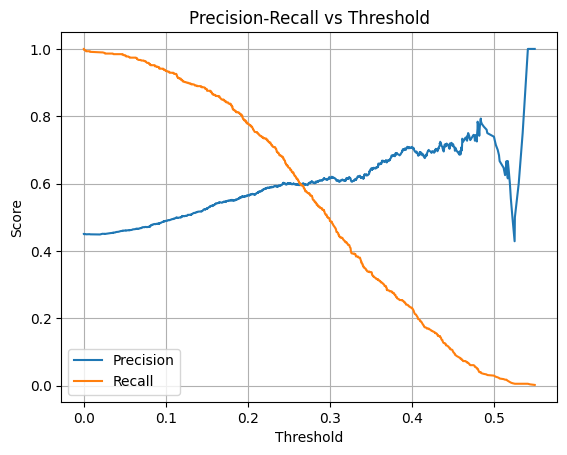

In [21]:
prob_combined = np.exp(log_prob_combined)
y_probas = prob_combined[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_probas)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [22]:
# Apply custom threshold
y_probas_custom = (y_probas >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.59      0.92      0.72       707
           1       0.71      0.23      0.35       579

    accuracy                           0.61      1286
   macro avg       0.65      0.58      0.53      1286
weighted avg       0.64      0.61      0.55      1286


